# L13d: Let's Train a NanoGPT on the Tiny Shakespeare Corpus
In this lab, we will train a small character-level decoder-only language model on the Tiny Shakespeare corpus and samples from it. The point is not to produce readable text. It is to make every moving part of the L13d lecture concrete and observable: a real causal-attention layer, a real next-token-prediction training loop, and real autoregressive sampling with greedy, temperature, and top-$k$ decoding.

> __Problem statement.__ We have a single text file (the complete works of Shakespeare concatenated into about $1.1$ million characters). We train a small language model on this file by next-token prediction, then use it to generate new text starting from a prompt.

The generated text will look like Shakespeare-shaped gibberish, and that is by design. Three points frame what to expect:

* __What the model cannot learn:__ At this scale the model has too few parameters and sees too few gradient updates to learn real spelling, grammar, or meaning. No individual generated word will be a real English word.
* __What the model does learn:__ From a character-level corpus in a short run, the model captures surface statistics such as where line breaks occur, that lines often begin with an uppercase name followed by a colon, that words are roughly four to six characters long, and that certain letter pairs ($th$, $ou$, $er$) are common while others ($qz$, $fj$) never appear.
* __Why that is the signal we want:__ Seeing the surface statistics reproduced in the output, even without real words, is the direct evidence that next-token training transferred the corpus statistics into the model weights.

That structural signature is what we will confirm in the sampling step.

The rest of this notebook works toward that goal in three tasks: preparing the corpus, building and training the model, and sampling from it.

> __Learning Objectives:__
>
> By the end of this lab, you should be able to:
>
> * __Build and train a decoder-only language model from scratch:__ Assemble a small transformer language model from causal attention and decoder-block components, and train it on a character-level corpus with next-token prediction cross-entropy loss.
> * __Generate text with three sampling strategies:__ Use greedy decoding, temperature sampling, and top-$k$ sampling on the trained model and explain by inspection how each strategy trades off determinism against diversity.
> * __Read a causal attention pattern:__ Plot the attention weights of one of the trained heads on a real input sequence and identify the lower-triangular structure imposed by the causal mask.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include("Include.jl"); # load the packages, source files and set the random seed for reproducibility

  Activating project at `~/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d`


### Constants
We'll use several constants throughout this lab. We define them here for easy reference and modification. See the comment next the constant for an explanation of its purpose, units, permissible values, etc.

In [2]:
# --- data / corpus constants -------------------------------------------------
CORPUS_PREVIEW_N_CHARS = 200          # number of leading chars of the corpus to print as a sanity check
ROUNDTRIP_TEST_STRING = "First Citizen:" # short string used to verify encode/decode is lossless
TRAIN_SPLIT_FRACTION = 0.9            # fraction of the encoded corpus used for training (rest is validation)

# --- model / architecture constants ------------------------------------------
MODEL_SEED = 42                       # RNG seed for reproducible weight initialization
D_MODEL = 64                          # width of token/position embeddings and residual stream
N_HEADS = 8                           # number of attention heads per block (must divide D_MODEL)
N_LAYERS = 4                          # number of stacked decoder blocks
CTX_LEN = 128                         # maximum context (sequence) length the model can attend over
D_FF = 4 * D_MODEL                    # hidden width of the position-wise feed-forward layer (standard 4x rule)
BATCHSIZE = 32                        # number of (X, Y) sequence pairs per mini-batch
CHECKPOINT_PATH = joinpath(_PATH_TO_DATA, "nanogpt_d$(D_MODEL)_h$(N_HEADS)_l$(N_LAYERS)_c$(CTX_LEN).jld2") # cached trained-weights path (filename encodes config)

# --- training constants ------------------------------------------------------
N_EPOCHS = 20                         # number of outer training epochs
N_ITERS_PER_EPOCH = 500               # number of mini-batch updates per epoch
LR = 3.0f-3                           # Adam learning rate (Float32)

# --- text-generation constants -----------------------------------------------
SAMPLE_PROMPT = "ROMEO:"              # seed string fed to the model before generating
GENERATION_LENGTH = 250               # number of characters to generate after the prompt
GREEDY_TEMPERATURE = 0                # tau = 0 selects the argmax token at each step (deterministic)
SAMPLING_TEMPERATURE = 0.8            # tau < 1 sharpens the softmax (more confident sampling)
TOP_K = 10                            # restrict sampling to the k highest-probability tokens
SAMPLING_RNG_SEED = 7                 # RNG seed so stochastic samples are reproducible

# --- attention-visualization constants ---------------------------------------
ATTN_RNG_SEED = 2026                  # RNG seed for selecting the validation batch to visualize
ATTN_SAMPLE_BATCHSIZE = 1             # only a single sequence is needed for the heatmap
ATTN_SAMPLE_INDEX = 1                 # which item in the batch to plot (batch size is 1, so always 1)
ATTN_BLOCK_INDEX = 1                  # which decoder block's attention to extract (1 = first layer)
ATTN_HEAD_INDEX = 1                   # which attention head within the block to plot

1

___

## Task 1: Prepare the Tiny Shakespeare corpus
The first task is to turn the raw text file into integer tensors the model can consume.

> __Corpus preparation.__ We (i) download the corpus from the char-rnn GitHub repo via [`download_shakespeare`](src/Shakespeare.jl) (cached locally after the first run), (ii) build a character-level vocabulary that maps each unique character to an integer id via [`build_vocab`](src/Shakespeare.jl), (iii) encode the full corpus as an integer vector with [`encode`](src/Shakespeare.jl), and (iv) hold out a tail fraction (set by `TRAIN_SPLIT_FRACTION`) as a validation set so we can monitor for overfitting.

The code block below returns the vocabulary as `vocab::CharVocabulary`, the integer-encoded training portion of the corpus as `TRAIN_DATA::Vector{Int}`, and the integer-encoded validation portion as `VAL_DATA::Vector{Int}`.

In [3]:
vocab, TRAIN_DATA, VAL_DATA = let

    # (i) load the Tiny Shakespeare corpus from the local cache, or download it if missing
    path = download_shakespeare(_PATH_TO_DATA);
    text = read(path, String);                                # read the entire corpus as a single String
    @info "corpus loaded" path n_chars=length(text)
    println();
    println("First $(CORPUS_PREVIEW_N_CHARS) characters of the corpus:");
    println("---");
    println(text[1:CORPUS_PREVIEW_N_CHARS]);                  # quick visual sanity check of the raw text
    println("---");

    # (ii) build a character-level vocabulary: unique chars -> integer ids (and inverse map)
    vocab = build_vocab(text);
    @info "vocabulary built" vocab_size=vocab.vocab_size
    println("Vocab characters: \"", join(sort(collect(keys(vocab.char_to_id))), ""), "\"")

    # encode/decode roundtrip sanity check: encode(decode(x)) should equal x
    test_str = ROUNDTRIP_TEST_STRING;
    ids = encode(test_str, vocab);                            # string -> Vector{Int} of token ids
    println("encoded \"", test_str, "\" -> ", ids);
    println("decoded back: \"", decode(ids, vocab), "\"");  # Vector{Int} -> String

    # (iii) encode the full corpus into a long vector of token ids, then (iv) split 90/10 into train/val
    data = encode(text, vocab);
    n_train = round(Int, TRAIN_SPLIT_FRACTION * length(data)); # number of training tokens
    TRAIN_DATA = data[1:n_train];                              # contiguous training slice
    VAL_DATA   = data[n_train+1:end];                          # held-out validation slice
    @info "train/val split" n_train=length(TRAIN_DATA) n_val=length(VAL_DATA)

    # return the vocab plus the two id-sequences from the let-block
    (vocab, TRAIN_DATA, VAL_DATA)
end;

┌ Info: corpus loaded
│   path = /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/data/input.txt
│   n_chars = 1115394
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y126sZmlsZQ==.jl:6



First 200 characters of the corpus:
---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
---


┌ Info: vocabulary built
│   vocab_size = 65
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y126sZmlsZQ==.jl:15


Vocab characters: "
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encoded "First Citizen:" -> [19, 48, 57, 58, 59, 2, 16, 48, 59, 48, 65, 44, 53, 11]
decoded back: "First Citizen:"


┌ Info: train/val split
│   n_train = 1003855
│   n_val = 111539
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y126sZmlsZQ==.jl:29


With the corpus encoded and split into training and validation partitions, we can now build the model that will be trained on them.

### Things to think about
* __What does the vocabulary size tell you about tokenizer granularity?__ The cell above prints `vocab_size` via `@info` and the full character set as `Vocab characters`. Without running any additional code, answer: given the size and contents of the vocabulary, is this a character-level or word-level tokenizer, and roughly how many token ids would it take to encode a typical five-letter English word compared to a word-level tokenizer that assigns one id per word?

___

## Task 2: Build and train the NanoGPT model
The second task is to assemble a decoder-only language model and train it on the corpus prepared in Task 1.

> __Model and training setup.__ We build a decoder-only [`NanoGPT`](src/NanoGPT.jl) with `N_LAYERS` transformer blocks ($L$), `N_HEADS` attention heads per block ($H$), model dimension $d$ set by `D_MODEL`, and context length $n_{\max}$ set by `CTX_LEN`. For a vocabulary of size $V$, the expected parameter count is $2 V d + n_{\max} d + L\,(12 d^{2} + 9 d) + 2 d$. We train with Adam at learning rate `LR` for `N_EPOCHS` epochs of `N_ITERS_PER_EPOCH` iterations each, drawing random `(input, target)` chunks via [`sample_batch`](src/Shakespeare.jl) and scoring them with [`nanogpt_loss`](src/NanoGPT.jl) on each iteration. The first run trains from scratch and saves a checkpoint under `data/`; subsequent runs detect the checkpoint and load it instead of retraining.

The code block below returns the trained model as `model::NanoGPT`, the vector of per-epoch mean training losses as `train_history::Vector{Float32}`, and the vector of per-epoch validation losses as `val_history::Vector{Float32}`.

In [4]:
model, train_history, val_history = let

    VOCAB = vocab.vocab_size;                                 # number of output classes for the LM head

    # build a fresh NanoGPT with the architecture constants defined above
    Random.seed!(MODEL_SEED);                                 # seed before init so weight draws are reproducible
    model = NanoGPT(VOCAB, D_MODEL, N_HEADS, N_LAYERS, CTX_LEN; d_ff = D_FF);
    @info "NanoGPT model built" n_params=n_parameters(model) vocab=VOCAB d_model=D_MODEL n_heads=N_HEADS n_layers=N_LAYERS ctx_len=CTX_LEN

    train_history = Float32[];                                # per-epoch mean training loss
    val_history   = Float32[];                                # per-epoch validation loss

    # if a cached checkpoint matching this config exists, load it; otherwise train from scratch
    if isfile(CHECKPOINT_PATH)
        @info "Loading pre-trained checkpoint" path=CHECKPOINT_PATH
        saved = JLD2.load(CHECKPOINT_PATH);                   # dict with model_state + loss histories
        Flux.loadmodel!(model, saved["model_state"]);         # copy saved params into the fresh model
        train_history = saved["train_history"];
        val_history   = saved["val_history"];
        @info "Loaded model from checkpoint"
    else
        @info "No checkpoint found, training from scratch..."
        Random.seed!(MODEL_SEED);                             # reseed so batch sampling is reproducible
        opt = Flux.setup(Adam(LR), model);                    # Adam optimizer state, one entry per param tensor
        for epoch in 1:N_EPOCHS
            epoch_losses = Float32[];                         # per-iter training losses within this epoch
            for it in 1:N_ITERS_PER_EPOCH
                # draw a random mini-batch of (input, next-token target) sequence pairs
                Xb, Yb = sample_batch(TRAIN_DATA, BATCHSIZE, CTX_LEN);
                # forward + backward pass: compute loss and gradients w.r.t. model params
                l, gs = Flux.withgradient(model) do m
                    nanogpt_loss(m, Xb, Yb)
                end
                push!(epoch_losses, l);
                Flux.update!(opt, model, gs[1]);              # Adam step: params .-= lr * adjusted_grad
            end
            train_l = mean(epoch_losses);                     # mean training loss over this epoch
            push!(train_history, train_l);
            # single-batch validation estimate (cheap proxy; fine for this small model)
            Xv, Yv = sample_batch(VAL_DATA, BATCHSIZE, CTX_LEN);
            val_l = nanogpt_loss(model, Xv, Yv);
            push!(val_history, val_l);
            @info "epoch" epoch train_loss=round(train_l, digits=4) val_loss=round(val_l, digits=4)
        end
        # persist trained weights + loss curves so subsequent runs skip retraining
        JLD2.jldsave(CHECKPOINT_PATH;
                      model_state = Flux.state(model),
                      train_history = train_history,
                      val_history = val_history);
        @info "Saved checkpoint" path=CHECKPOINT_PATH
    end

    # return the trained model and both loss histories from the let-block
    (model, train_history, val_history)
end;

┌ Info: NanoGPT model built
│   n_params = 215552
│   vocab = 65
│   d_model = 64
│   n_heads = 8
│   n_layers = 4
│   ctx_len = 128
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y132sZmlsZQ==.jl:8
┌ Info: Loading pre-trained checkpoint
│   path = /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/data/nanogpt_d64_h8_l4_c128.jld2
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y132sZmlsZQ==.jl:15
┌ Info: Loaded model from checkpoint
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y132sZmlsZQ==.jl:20


### Training loss curve
> __Sanity check.__ Before moving on, we plot the per-epoch training and validation losses. Both should decrease steadily and stay close together, which means the model is learning the corpus without overfitting.

The cell below plots both curves on a single axis.

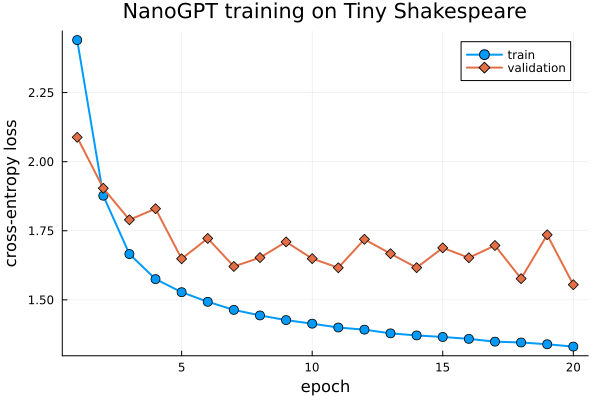

In [5]:
let
    # plot the training-loss curve as a function of epoch
    plot(1:length(train_history), train_history;
         xlabel = "epoch", ylabel = "cross-entropy loss",
         label = "train",
         title = "NanoGPT training on Tiny Shakespeare",
         linewidth = 2, marker = :circle, markersize = 5,
         legend = :topright);
    # overlay the validation-loss curve; a growing gap signals overfitting
    plot!(1:length(val_history), val_history;
          label = "validation",
          linewidth = 2, marker = :diamond, markersize = 5)
end

### Things to think about
* __Does the loss curve show signs of overfitting?__ Look at the per-epoch training and validation losses above. Without retraining: (a) Do both curves decrease over the course of training, indicating that the model is actually learning from the corpus? (b) Do they stay close across all epochs, or does a visible gap open up near the end of training, with validation loss rising while training loss keeps falling? Put the two observations together: based on these curves alone, is the model underfit, well fit, or starting to overfit the training slice?

___

## Task 3: Sample from the model and visualize causal attention
With a trained model in hand, we generate text with three decoding strategies and then inspect one head's attention weights:

* __Shared conditions:__ All three sampling strategies use the same prompt (`SAMPLE_PROMPT`) and the same generation length (`GENERATION_LENGTH`), so any differences in output come from the decoding rule, not the prompt.
* __How to read the output:__ Do not read the generated text for meaning, read it for structure. In every sample you should see line breaks, an uppercase speaker name followed by a colon at the start of each line, and tokens that resemble English words in length and letter frequency even when they are not real words.
* __Diagnostic contrast between decoders:__ Greedy decoding is deterministic and typically gets stuck repeating a short phrase, temperature sampling breaks the loop but occasionally emits improbable characters, and top-$k$ sampling breaks the loop while filtering out the worst of those improbable tokens.

The attention heatmap then confirms the causal-mask pattern from the lecture on a real input sequence. Let's begin by looking at decoding strategies.

### Decoding strategies
At the end of training, we have a model that can predict the next character given a sequence of previous characters. To generate text, we start with a prompt and repeatedly sample the next character from the model's output distribution, appending it to the input sequence and feeding it back into the model. The way we sample the next character defines our decoding strategy.

> __Three decoding rules.__ Greedy decoding picks the highest-logit token at every step; it is deterministic and equivalent to the $\tau \to 0$ limit of temperature sampling. Temperature sampling scales the logits by $1/\tau$ before softmax; with $\tau < 1$ the distribution stays sharp but is no longer deterministic. Top-$k$ sampling is temperature sampling restricted to the $k$ highest-logit tokens at every step.

The code blocks below run all three decoders via [`sample_text`](src/Sample.jl) on the same prompt and print the generated text for comparison. First, what is the prompt and generation length?

In [6]:
SAMPLE_PROMPT, GENERATION_LENGTH

("ROMEO:", 250)

Let's start by looking at the argmax strategy (greedy decoding). In this case, we take the highest-logit token at every step, which is equivalent to the $\tau \to 0$ limit of temperature sampling. This strategy is deterministic and typically gets stuck in a short loop.

In [7]:
sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = GREEDY_TEMPERATURE) |> println

ROMEO:
Why, then, that thou hast should be the season
That thou shalt stands to the seas, and the seas
That the seas of the season of the seas.

LUCIO:
The shall be the shame of the shame of the seas.

CLARENCE:
The shall be the sun of the sun of the seas.


Next, we look at temperature sampling with $\tau$ set by `SAMPLING_TEMPERATURE`. This strategy is no longer deterministic and produces more diverse output, but it can occasionally emit improbable characters. This output is random: if we change the seed and run it again we get a different sample.

In [8]:
sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = SAMPLING_TEMPERATURE, rng = MersenneTwister(SAMPLING_RNG_SEED)) |> println

ROMEO:
Where is your facely hour poison that father.

WARWICK:
My lord, my lord? that is the effect.
But I cannot be his did, sir, I say, as my father's char
The house, a payers of every wepone to kill be
the inficncers in our worth winderst contempt and
h



Finally, we look at top-$k$ sampling with $k$ set by `TOP_K`. This strategy also breaks the loop but filters out the worst of the improbable tokens, producing more coherent output than temperature sampling alone.

In [9]:
sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = SAMPLING_TEMPERATURE, top_k = TOP_K, rng = MersenneTwister(SAMPLING_RNG_SEED)) |> println

ROMEO:
Where is your graced it is sheep of my brother
Will beast this salm'd and stand of like a doth head britten
and to this face of the wind for the face;
Her horses' ancour bloods to the duked:
Nor I, were thou art for our worth will proud,
That may be


### Causal attention heatmap
> __Attention extraction.__ Each attention head in the model produces a $T\times T$ matrix of attention weights at each forward pass, where $T$ is the context length and $H$ is the number of heads. Because of the causal mask, every row $i$ has zero weight at all columns $j > i$, so the matrix is strictly lower-triangular. We pick a random input sequence from the validation set, run the embeddings and the first decoder block's pre-norm on it, and call [`causal_attention_weights`](src/CausalAttention.jl) to recover the $(T, T, H, B)$ attention tensor from the first decoder block, where $B$ is the batch dimension.

Since we only need a single sequence to draw one heatmap, we set `ATTN_SAMPLE_BATCHSIZE = 1`, so $B = 1$ and the returned tensor has shape $(T, T, H, 1)$ (a single-sequence batch). The code block below returns that attention-weight tensor as `attn_w::Array{Float32, 4}` and the decoded character string of the input sequence as `input_chars::String`.

In [10]:
attn_w, input_chars = let

    # draw a single validation sequence to visualize attention on
    Random.seed!(ATTN_RNG_SEED);
    Xb, _ = sample_batch(VAL_DATA, ATTN_SAMPLE_BATCHSIZE, model.ctx_len);
    input_chars = decode(Xb[:, ATTN_SAMPLE_INDEX], vocab);    # string form of the sampled ids (for tick labels)
    println("Input sequence:");
    println("---");
    println(input_chars);
    println("---");

    # manually replay the embedding + pre-norm path so we can call the attention layer directly
    d_model = size(model.tok_emb, 1);                         # embedding width
    T       = model.ctx_len;                                  # sequence length we'll attend over
    flat_ids = vec(Xb);                                       # flatten to 1D for lookup
    tok_e    = model.tok_emb[:, flat_ids];                    # (d_model, T) token-embedding lookup
    # add positional embeddings and reshape to the (d_model, T, B) tensor the block expects
    H0       = reshape(tok_e, d_model, T, 1) .+ reshape(model.pos_emb[:, 1:T], d_model, T, 1);
    H_norm   = model.blocks[ATTN_BLOCK_INDEX].ln1(H0);        # pre-attention LayerNorm (pre-norm transformer)
    # pull the softmaxed attention weights (shape (T, T, n_heads, B)) from the chosen block
    attn_w   = causal_attention_weights(model.blocks[ATTN_BLOCK_INDEX].attn, H_norm);
    @info "attention weights" shape=size(attn_w)

    # return the weights tensor + the decoded input string
    (attn_w, input_chars)
end;

Input sequence:
---
t, and welcome to my house:
My banquet is to close our stomachs up,
After our great good cheer. Pray you, sit down;
For now we s
---


┌ Info: attention weights
│   shape = (128, 128, 8, 1)
└ @ Main /Users/jdv27/Desktop/julia_work/CHEME-5820-Instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-13/L13d/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y151sZmlsZQ==.jl:22


In [11]:
input_chars

"t, and welcome to my house:\nMy banquet is to close our stomachs up,\nAfter our great good cheer. Pray you, sit down;\nFor now we s"

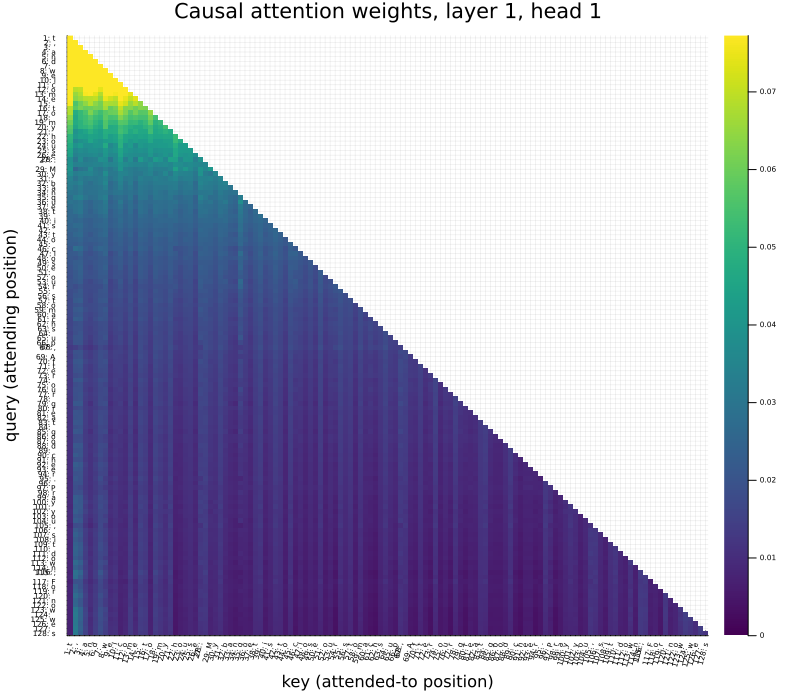

In [12]:
let
    # slice out a single (T x T) attention matrix for the chosen head and batch item
    A = Float64.(attn_w[:, :, ATTN_HEAD_INDEX, ATTN_SAMPLE_INDEX]);
    T = size(A, 1);                                                      # sequence length
    # mask the causal-zeroed upper triangle with NaN so it renders as background instead of
    # sharing the darkest color with genuinely small nonzero attention weights
    for i in 1:T, j in 1:T
        if j > i
            A[i, j] = NaN
        end
    end
    # clip the color scale at the 99th percentile of the lower-triangular entries so the
    # (1,1) = 1 outlier does not compress the rest of the distribution into near-black
    nz   = filter(!isnan, A)
    vmax = quantile(nz, 0.99)
    # build tick labels that show each position's index and character (escape newlines for readability)
    labels = [c == '\n' ? "\\n" : string(c) for c in input_chars];
    tick_labels = ["$(i): $(labels[i])" for i in 1:T];
    # rows = queries (attending position), columns = keys (attended-to position)
    # lower-triangular structure is enforced by the causal mask inside CausalAttention
    heatmap(1:T, 1:T, A;
            xlabel = "key (attended-to position)",
            ylabel = "query (attending position)",
            title  = "Causal attention weights, layer $(ATTN_BLOCK_INDEX), head $(ATTN_HEAD_INDEX)",
            color  = :viridis,
            clims  = (0.0, vmax),
            background_color_inside = :white,
            size   = (800, 700),
            yflip  = true,                                               # put query position 1 at the top
            xticks = (1:T, tick_labels),
            yticks = (1:T, tick_labels),
            xrotation = 75,
            xtickfont = font(5),
            ytickfont = font(5))
end

### Things to think about
* __Does the causal mask show up in the heatmap, and does the decoding contrast match the theory?__ Using only the three generated samples and the attention heatmap you already produced in this task (no new code, no retraining): (a) Is every row of the attention heatmap strictly lower-triangular, with zero weight on the upper-right entries, as predicted by the causal mask that sets scores at $(i, j)$ with $j > i$ to $-10^{9}$ before softmax? (b) Comparing the greedy, temperature, and top-$k$ samples printed above, which decoder repeats the shortest phrase, and which produces the most varied text? Put the two observations together: do the plots and samples confirm the lower-triangular structure of causal attention and the determinism-versus-diversity tradeoff from the decoding rules?
___

## Summary
This notebook trained a small decoder-only language model on Tiny Shakespeare and sampled from it with greedy, temperature, and top-$k$ decoding. The output is not readable English, and it was not supposed to be. What we wanted to see, and did see, is that the full transformer machinery from the lecture can be stood up end-to-end, trained with next-token cross-entropy, and made to produce text whose surface structure reflects the training corpus.

> __Key Takeaways:__
>
> * __A small decoder-only model is enough to see the lecture's claims in practice:__ With a modest parameter count and a short training run, the model produces output with the right surface structure (line breaks, character names, speech tags) even though no individual word is real English. That is the expected outcome for a character-level model at this scale, and it is the evidence that next-token training is doing its job.
> * __Greedy decoding fails as predicted:__ Picking the highest-logit token at every step drops the model into a repetition loop. Temperature and top-$k$ sampling fix this by injecting controlled randomness, which is why production systems never use pure greedy decoding.
> * __The causal attention heatmap visualizes the causal mask directly:__ A trained head's attention weights are strictly lower-triangular, with all upper-triangular entries equal to zero. This is the architectural constraint that makes autoregressive training parallelizable.

To push the same architecture toward readable output, scale is the lever:

* __Train longer on more data:__ Increase the parameter count, the corpus size, and the number of gradient steps; at some point the model has enough capacity and exposure to learn word-level regularities rather than just character-level ones.
* __Change the tokenizer:__ Replace character-level tokens with subword or word-level tokens so the model no longer has to relearn that common letter sequences form words.

The causal mask, decoder block, embedding tables, and cross-entropy loss are already the production components.
___